In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.metrics import accuracy_score, classification_report, recall_score
import wandb
import joblib
import pandas as pd


In [3]:
config = {
            "tfidf_titulo_max_features": 2000,
            "tfidf_descripcion_max_features": 4000,
            "tfidf_tags_max_features": 2000,
            "tfidf_subtitulos_max_features": 5000,
            "ngram_range": (1,2),
            "svd_components": 300,
            "depth_values": range(1,100),
            'criterion': 'entropy',
            "cv_folds": 5
        }
preprocess = ColumnTransformer(
        transformers=[
            ("Titulo", TfidfVectorizer(max_features=config["tfidf_titulo_max_features"], ngram_range=config["ngram_range"]), "Titulo"),
            ("Descripcion", TfidfVectorizer(max_features=config["tfidf_descripcion_max_features"], ngram_range=config["ngram_range"]), "Descripcion"),
            ("Tags", TfidfVectorizer(max_features=config["tfidf_tags_max_features"], ngram_range=config["ngram_range"]), "Tags"),
            ("Subtitulos", TfidfVectorizer(max_features=config["tfidf_subtitulos_max_features"], ngram_range=config["ngram_range"]), "Subtitulos"),
            ("Generos", OneHotEncoder(), ["Generos"]),
            ("Duracion", StandardScaler(), ["Duracion"])
        ]
    )

In [4]:
best_n_leafs = None
best_acc = 0
best_model= None

In [ ]:
from comun.modelos_utils import *
def download_model_dfs():
    with open("Private/claves.json", "r", encoding="utf-8") as archivo:
        claves = json.load(archivo)
        df_train = download_dataframe_minio("pd1", "grupo1/modelos/train_no_filters", claves, "parquet")
        df_validation = download_dataframe_minio("pd1", "grupo1/modelos/validation_no_filters", claves, "parquet")
        df_test = download_dataframe_minio("pd1", "grupo1/modelos/test_no_filters", claves, "parquet")
        df_train['Duracion'] = df_train['Duracion'].apply(iso_a_minutos)
        df_validation['Duracion'] = df_validation['Duracion'].apply(iso_a_minutos)
        df_test['Duracion'] = df_test['Duracion'].apply(iso_a_minutos)
        return df_train, df_validation, df_test
df_train, df_validation, df_test = download_model_dfs()

In [8]:
df_train = pd.concat([df_train, df_validation])
X_train = df_train.drop(columns=["Rango_edad"])
y_train = df_train["Rango_edad"] != 'Adult'
X_test = df_test.drop(columns=["Rango_edad"])
y_test = df_test["Rango_edad"] != 'Adult'

In [9]:
results_table = pd.DataFrame(columns=['depth','cv_accuracy'])

In [32]:
for i in range(30,33):
    pipeline = Pipeline([
            ("preprocess", preprocess),
            ("svd", TruncatedSVD(n_components=config["svd_components"])),
            ("model", DecisionTreeClassifier(max_depth=i, criterion='gini'))
        ])
    scores = cross_val_score(
            pipeline,
            X_train,
            y_train,
            cv=config["cv_folds"],
            scoring="recall",
            n_jobs=-1
        )
    print(scores)

[0.92679409 0.91597548 0.90840245 0.90512266 0.91341991]
[0.91525424 0.91489362 0.90984493 0.91233766 0.92063492]
[0.92426974 0.90623873 0.90840245 0.91269841 0.92063492]


In [52]:
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('svd', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('Titulo', ...), ('Descripcion', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differen

In [27]:
best_model = Pipeline([
        ("preprocess", preprocess),
        ("svd", TruncatedSVD(n_components=config["svd_components"])),
        ("model", DecisionTreeClassifier(max_depth=50, criterion='gini'))
    ])
best_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('svd', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('Titulo', ...), ('Descripcion', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differen

In [28]:
pred_test = best_model.predict(X_test)
test_acc = recall_score(y_test, pred_test)

print("\n--- RESULTADOS EN TEST ---")
print("Accuracy:",recall_score(y_test, pred_test))
print("\nClassification Report:")
print(classification_report(y_test, pred_test))


--- RESULTADOS EN TEST ---
Accuracy: 0.9167020824479388

Classification Report:
              precision    recall  f1-score   support

       False       0.92      0.90      0.91      2350
        True       0.90      0.92      0.91      2353

    accuracy                           0.91      4703
   macro avg       0.91      0.91      0.91      4703
weighted avg       0.91      0.91      0.91      4703



In [29]:
max(best_model['model'].feature_importances_)

np.float64(0.6308123568367908)

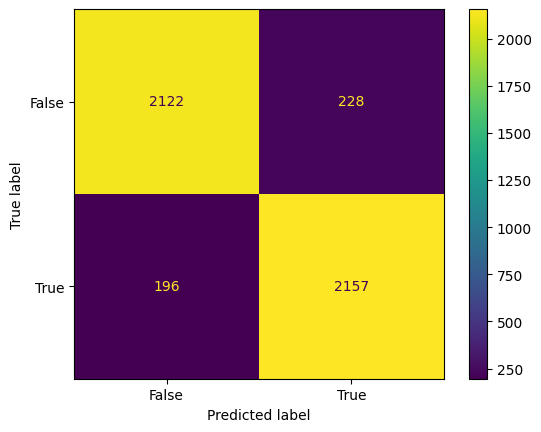

In [30]:
cm = confusion_matrix(y_test, pred_test, labels=best_model['model'].classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=best_model['model'].classes_)
disp.plot()
plt.show()

In [13]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

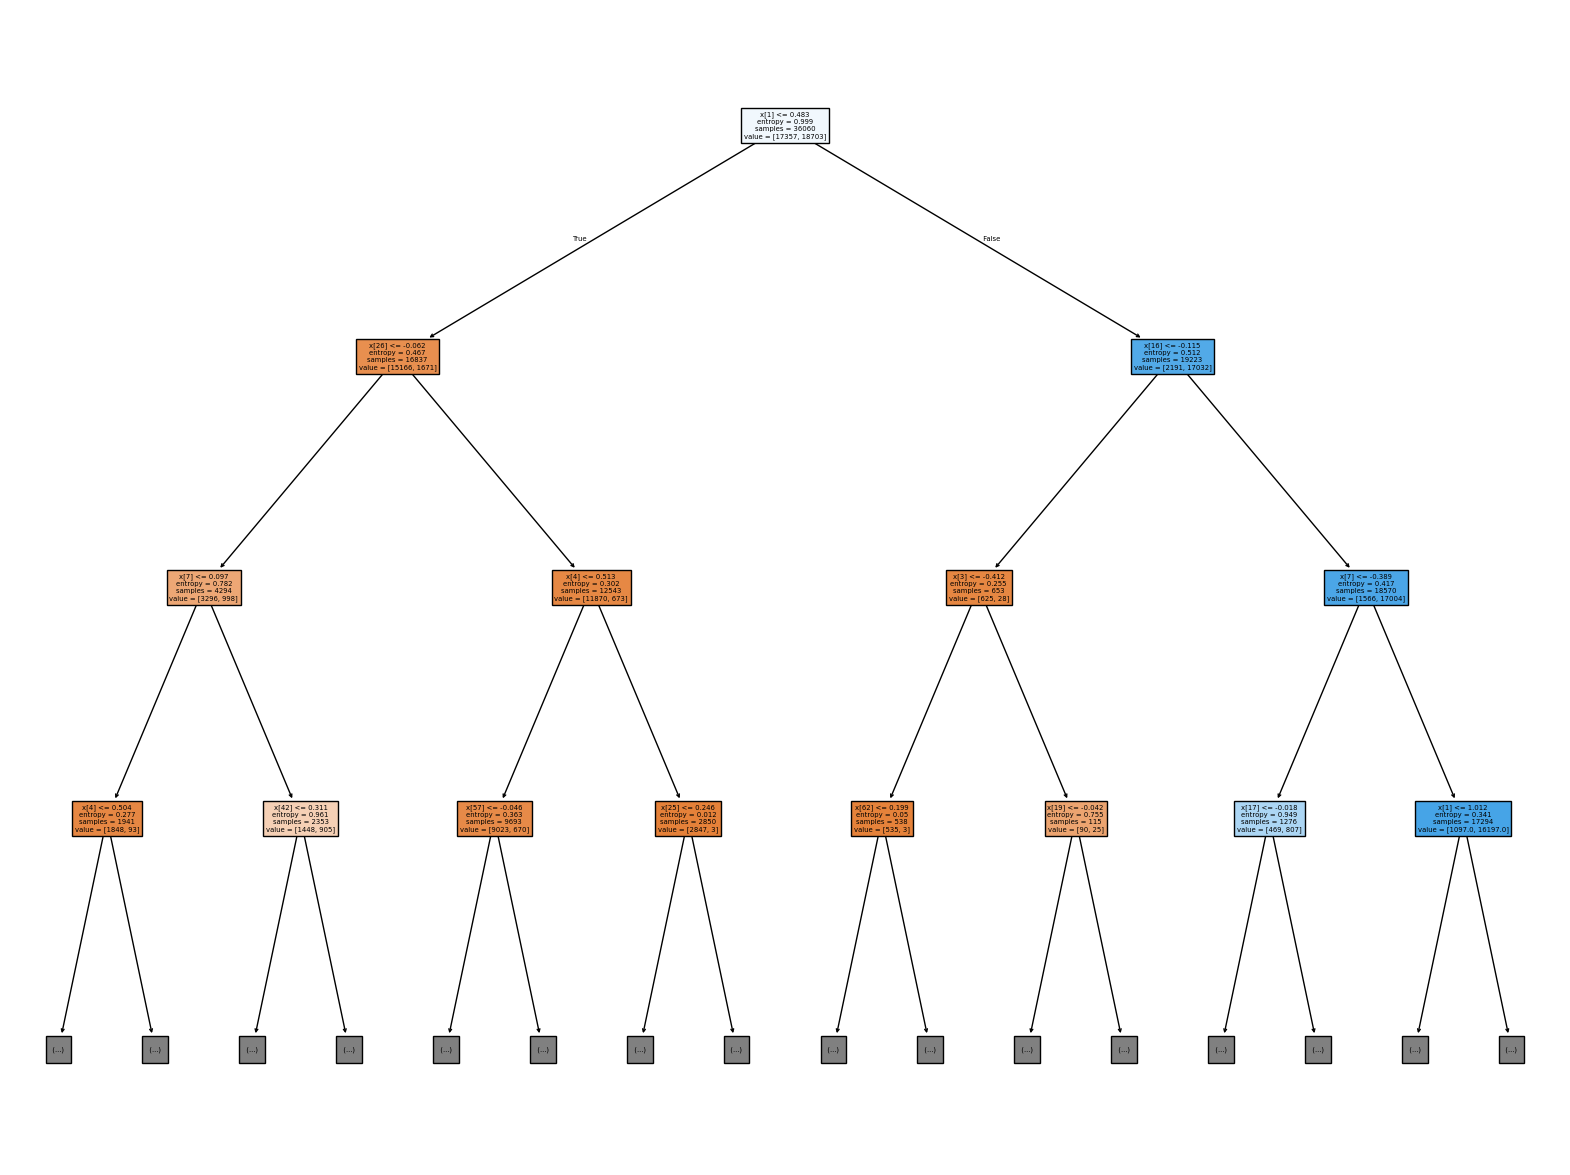

In [42]:
fig, ax = plt.subplots(figsize=(20,15))
plot_tree(best_model['model'], filled=True, max_depth=3)#, feature_names=X_train.keys(), class_names=best_model.classes_, filled=True, rounded=True, impurity=False, fontsize=8)
plt.show()